## Import Library

In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

## Load Dataset

In [ ]:
df_main = pd.read_csv('dataset_main.csv')
df_main

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Engineer,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Engineer,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Engineer,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
...,...,...,...,...,...,...,...,...,...,...,...
995,996,Brenda Williams,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,NaN,Cybersecurity Engineer,Reject,114364,9,60
996,997,Colleen Hicks,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,998,Michelle Molina,"TensorFlow, NLP",0,B.Tech,Google ML,AI Engineer,Hire,113855,9,65
998,999,Danielle Horn,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Engineer,Hire,83146,10,100


In [ ]:
df_added1 = pd.read_csv('dataset_added1.csv')
df_added1

,CandidateID,Name,Age,Education,Skills,Interests,Job Role,Recommendation_Score
0,1,John Doe,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,2,Jane Smith,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,3,Bob Johnson,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88
3,4,Emily Davis,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,AI Engineer,0.93
4,5,Michael Brown,30,Master's,Project Management;Communication;Agile,Business;Management,Project Manager,0.87
...,...,...,...,...,...,...,...,...
195,196,Easton Perry,38,Bachelor's,Copywriting;SEO;Social Media,Finance;Analytics,UX Researcher,0.94
196,197,Aurora Jenkins,39,Master's,Network Security;Linux;Python,Marketing;Communications,Cybersecurity Engineer,0.95
197,198,Camden Collins,40,PhD,C#;.NET;Software Design,Cybersecurity;Technology,Data Scientist,0.85
198,199,Hazel Gray,41,Bachelor's,Data Visualization;Python;R,Academia;Research,Cloud Engineer,0.86


In [ ]:
df_added2 = pd.read_csv('dataset_added2.csv')
df_added2

,candidate_id,Skills,Education,experience_level,Job Role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer
...,...,...,...,...,...
995,996,"HR Management, Recruitment, Employee Relations",Master's in Human Resources,Senior,HR
996,997,"C#, .NET Core, Azure, SQL Server",Bachelor's in Computer Science,Mid,C# Developer
997,998,"Swift, iOS, Xcode, UI/UX",Bachelor's in Computer Science,Entry,Mobile Developer
998,999,"Network Security, Ethical Hacking, SIEM",Master's in Cybersecurity,Senior,Cybersecurity Engineer


In [ ]:
# Menggabungkan tiga file dataset menjadi satu dataframe
df_combined = pd.concat([df_main, df_added1, df_added2], ignore_index=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Resume_ID               1000 non-null   float64
 1   Name                    1200 non-null   object 
 2   Skills                  2200 non-null   object 
 3   Experience (Years)      1000 non-null   float64
 4   Education               2200 non-null   object 
 5   Certifications          726 non-null    object 
 6   Job Role                2200 non-null   object 
 7   Recruiter Decision      1000 non-null   object 
 8   Salary Expectation ($)  1000 non-null   float64
 9   Projects Count          1000 non-null   float64
 10  AI Score (0-100)        1000 non-null   float64
 11  CandidateID             200 non-null    float64
 12  Age                     200 non-null    float64
 13  Interests               200 non-null    object 
 14  Recommendation_Score    200 non-null    

## Pemilihan dan Pembersihan Data

In [ ]:
# Memilih atribut utama yang akan digunakan dalam pemodelan
df_selected = df_combined[['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Projects Count']]
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Skills              2200 non-null   object 
 1   Experience (Years)  1000 non-null   float64
 2   Education           2200 non-null   object 
 3   Certifications      726 non-null    object 
 4   Job Role            2200 non-null   object 
 5   Projects Count      1000 non-null   float64
dtypes: float64(2), object(4)
memory usage: 103.3+ KB


In [ ]:
# Menentukan target kelas profesi yang akan digunakan untuk klasifikasi
target_roles = ['Data Scientist', 'AI Engineer', 'Cybersecurity Engineer']

# Menyaring data hanya untuk target kelas profesi yang dipilih
df_filtered = df_selected[df_selected['Job Role'].isin(target_roles)].copy()

# Menampilkan jumlah data dan contoh nilai Job Role setelah proses filter
print("Jumlah data setelah filter:", len(df_filtered))
print("Contoh nilai Job Role:", df_filtered['Job Role'].unique())

Jumlah data setelah filter: 1001
Contoh nilai Job Role: ['AI Engineer' 'Data Scientist' 'Cybersecurity Engineer']


In [ ]:
# Mengisi Missing Value pada Certifications dengan nilai "None"
df_filtered.loc[:,'Certifications'] = df_filtered['Certifications'].fillna("None")

# Mengisi Missing Value pada Experience dan Projects Count dengan nilai rata-rata (mean)
num_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df_filtered.loc[:, ['Experience (Years)', 'Projects Count']] = num_imputer.fit_transform(
    df_filtered[['Experience (Years)', 'Projects Count']]
)

# Mengubah hasil imputasi menjadi bilangan bulat
df_filtered.loc[:, 'Experience (Years)'] = df_filtered['Experience (Years)'].round().astype(int)
df_filtered.loc[:, 'Projects Count'] = df_filtered['Projects Count'].round().astype(int)

## Transformasi Fitur

In [ ]:
# Membuat manual mapping untuk mengubah jenjang pendidikan menjadi nilai numerik
education_map = {
    'None': 0,
    'B.Sc': 1,
    'B.Tech': 1,
    "Bachelor's": 1,
    "Bachelor's in Statistics": 1,
    "Bachelor's in Cybersecurity": 1,
    'MBA': 2,
    'M.Tech': 2,
    "Master's": 2,
    "Master's in Data Science": 2,
    "Master's in Cybersecurity": 2,
    'PhD': 3,
    "PhD in Artificial Intelligence": 3
}

# Menerapkan mapping ke kolom Education dan membuat kolom baru Education_Encoded
df_filtered['Education_Encoded'] = df_filtered['Education'].map(education_map)

# Menampilkan contoh hasil encoding
print("Contoh hasil encode Education:")
print(df_filtered[['Education', 'Education_Encoded']].drop_duplicates())

Contoh hasil encode Education:
                           Education  Education_Encoded
0                               B.Sc                  1
1                                MBA                  2
3                             B.Tech                  1
6                             M.Tech                  2
15                               PhD                  3
1000                      Bachelor's                  1
1006                        Master's                  2
1200        Master's in Data Science                  2
1215     Bachelor's in Cybersecurity                  1
1221  PhD in Artificial Intelligence                  3
1226        Bachelor's in Statistics                  1
1238       Master's in Cybersecurity                  2


In [ ]:
# Membuat dan menerapkan TF-IDF Vectorizer untuk kolom Skills
skills_vectorizer = TfidfVectorizer()
skills_tfidf = skills_vectorizer.fit_transform(df_filtered['Skills'])

# Membuat dan menerapkan TF-IDF Vectorizer untuk kolom Certifications
certs_vectorizer = TfidfVectorizer()
certs_tfidf = certs_vectorizer.fit_transform(df_filtered['Certifications'])

# Menampilkan ukuran matriks hasil TF-IDF
print("Ukuran TF-IDF Skills:", skills_tfidf.shape)
print("Ukuran TF-IDF Certifications:", certs_tfidf.shape)

Ukuran TF-IDF Skills: (1001, 66)
Ukuran TF-IDF Certifications: (1001, 8)


## Penentuan Fitur Akhir (X) dan Kelas (y)

In [ ]:
# Mengambil fitur numerik Education_Encoded, Experience, dan Projects Count
education = df_filtered[['Education_Encoded']].values
experience = df_filtered[['Experience (Years)']].values
projects = df_filtered[['Projects Count']].values

# Menggabungkan semua fitur (TF-IDF dan fitur numerik) menjadi satu matriks fitur akhir
X = hstack([skills_tfidf, certs_tfidf, education, experience, projects])

# Menentukan atribut label target (kelas) yaitu Job Role
y = df_filtered['Job Role']

print("Ukuran akhir fitur X:", X.shape)
print("Jumlah label unik:", y.nunique())

Ukuran akhir fitur X: (1001, 77)
Jumlah label unik: 3


## Pembagian Data Training dan Data Testing

In [ ]:
# pembagian data training & testing 80%:20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9
)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

Jumlah data latih: 800
Jumlah data uji: 201


## Pelatihan Model

In [ ]:
# Inisialisasi model klasifikasi Multinomial Naive Bayes
model = MultinomialNB()

# Melatih model dengan data latih
model.fit(X_train, y_train)

MultinomialNB()

## Pengujian Model

In [ ]:
# prediksi data uji (80%:20%)
y_predict = model.predict(X_test)
y_predict

array(['Cybersecurity Engineer', 'Data Scientist',
       'Cybersecurity Engineer', 'Data Scientist', 'Data Scientist',
       'Data Scientist', 'AI Engineer', 'Data Scientist',
       'Cybersecurity Engineer', 'AI Engineer', 'Data Scientist',
       'AI Engineer', 'Data Scientist', 'AI Engineer', 'AI Engineer',
       'AI Engineer', 'Cybersecurity Engineer', 'AI Engineer',
       'Cybersecurity Engineer', 'Data Scientist',
       'Cybersecurity Engineer', 'Cybersecurity Engineer',
       'Cybersecurity Engineer', 'AI Engineer', 'Data Scientist',
       'Cybersecurity Engineer', 'Data Scientist',
       'Cybersecurity Engineer', 'Cybersecurity Engineer',
       'Cybersecurity Engineer', 'Cybersecurity Engineer',
       'Cybersecurity Engineer', 'Data Scientist', 'AI Engineer',
       'Data Scientist', 'Data Scientist', 'AI Engineer',
       'Data Scientist', 'Data Scientist', 'Cybersecurity Engineer',
       'Cybersecurity Engineer', 'Data Scientist',
       'Cybersecurity Engineer', '

## Evaluasi Model

Akurasi: 0.9751243781094527

Laporan Klasifikasi:
                         precision    recall  f1-score   support

           AI Engineer       0.98      0.94      0.96        53
Cybersecurity Engineer       0.99      0.99      0.99        67
        Data Scientist       0.96      0.99      0.98        81

              accuracy                           0.98       201
             macro avg       0.98      0.97      0.97       201
          weighted avg       0.98      0.98      0.98       201



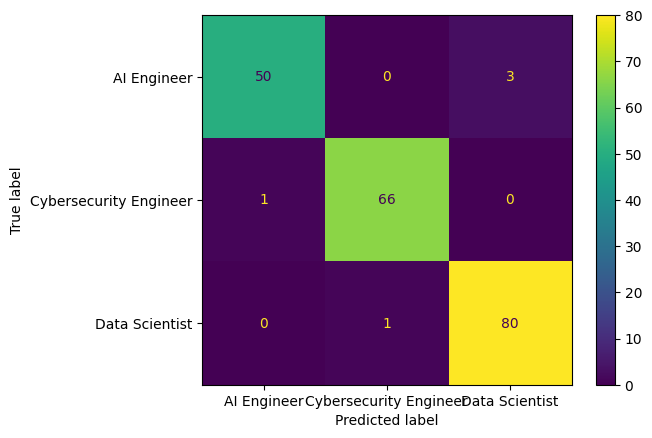

In [ ]:
# Mengevaluasi hasil prediksi menggunakan akurasi, laporan klasifikasi, dan confusion matrix (80%:20%)
print("Akurasi:", accuracy_score(y_test, y_predict))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_predict))
ConfusionMatrixDisplay.from_predictions(y_test, y_predict)

# Test New Data

In [ ]:
# Contoh input kandidat baru
new_candidate = {
    "Skills": "Python, Machine Learning, Pytorch",
    "Certifications": "None",
    "Education": "M.Tech",
    "Experience (Years)": 2,
    "Projects Count": 3
}


# Transform teks
skills_vec = skills_vectorizer.transform([new_candidate["Skills"]])
certs_vec = certs_vectorizer.transform([new_candidate["Certifications"]])

# Encoding numerik
edu = np.array([[education_map.get(new_candidate["Education"], 0)]])
exp = np.array([[new_candidate["Experience (Years)"]]])
proj = np.array([[new_candidate["Projects Count"]]])

# Gabungkan semua fitur
final_input = hstack([skills_vec, certs_vec, edu, exp, proj])

# Melakukan Klasifikasi
predicted_role = model.predict(final_input)

print("Klasifikasi Job Role:", predicted_role[0])

Prediksi Job Role: AI Engineer


## Export Model

In [ ]:
# Simpan model
joblib.dump(model, "model.pkl")

# Simpan vectorizer skills
joblib.dump(skills_vectorizer, "skills_vectorizer.pkl")

# Simpan vectorizer certifications
joblib.dump(certs_vectorizer, "certs_vectorizer.pkl")

# Simpan education map
joblib.dump(education_map, "education_map.pkl")

['education_map.pkl']